In [1]:
import torch
import os
from torch import nn
from data_utils import get_resnet_imagenet_preprocess
from pathlib import Path

import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import scale_cam_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import matplotlib.pyplot as plt
from PIL import Image
import pickle as pkl

from train_backbones import CNNClassifier

/Users/zhijiezhu/Developer/Research/Label-free-CBM/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


In [2]:
class MyGradCAM(GradCAM):
    def __init__(self, model, target_layers, target_size: tuple[int, int] = (7, 7), reshape_transform=None):
        super(MyGradCAM, self).__init__(model, target_layers, reshape_transform)
        self.target_size = target_size

    def compute_cam_per_layer(self, input_tensor: torch.Tensor, targets: list[torch.nn.Module], eigen_smooth: bool) -> list[np.ndarray]:
        activations_list = [a.cpu().data.numpy() for a in self.activations_and_grads.activations]
        grads_list = [g.cpu().data.numpy() for g in self.activations_and_grads.gradients]

        cam_per_target_layer = []
        # Loop over the saliency image from every layer
        for i in range(len(self.target_layers)):
            target_layer = self.target_layers[i]
            layer_activations = None
            layer_grads = None
            if i < len(activations_list):
                layer_activations = activations_list[i]
            if i < len(grads_list):
                layer_grads = grads_list[i]

            cam = self.get_cam_image(input_tensor, target_layer, targets, layer_activations, layer_grads, eigen_smooth)
            cam = np.maximum(cam, 0)
            scaled = scale_cam_image(cam, self.target_size)
            cam_per_target_layer.append(scaled[:, None, :])

        return cam_per_target_layer

    def aggregate_multi_layers(self, cam_per_target_layer: np.ndarray) -> np.ndarray:
        return np.squeeze(cam_per_target_layer[0])

In [4]:
ckpt_dir = Path("saved_models/cub_cbm_2025_09_13_15_59")
weight_b_g = torch.load(ckpt_dir / "b_g.pt", map_location="cpu")
weight_W_c = torch.load(ckpt_dir / "W_c.pt", map_location="cpu")
weight_W_g = torch.load(ckpt_dir / "W_g.pt", map_location="cpu")

# FIXME: feature sizes
proj_layer = torch.nn.Linear(in_features=1024, out_features=112, bias=False)
final_layer = torch.nn.Linear(112, 200)

proj_layer.weight.data = weight_W_c[:-1]
final_layer.weight.data = weight_W_g[...,:-1]
final_layer.weight.bias = weight_b_g

In [6]:
net_name = "resnet34"
net = CNNClassifier(backbone_name=net_name)
state_dict = torch.load(f"./checkpoints/{net_name}_cub.pth", map_location="cpu")
net.load_state_dict(state_dict=state_dict)
net.classifier = nn.Sequential(proj_layer, final_layer)
net.eval()

CNNClassifier(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stat

In [7]:
import re

def get_module(model, path):
    """Safely access a nested module using a dot-separated path with optional indexing."""
    module = model
    parts = re.split(r'(\[.*?\])', path)  # Split on brackets, keeping them
    for part in parts:
        if not part:
            continue
        if part.startswith('[') and part.endswith(']'):
            index = int(part[1:-1])
            module = module[index]
        else:
            module = getattr(module, part.lstrip("."))
    return module

cam_layer = {
    "densenet161": "features[0].norm5",
    "densenet121": "features[0].norm5",
    "resnet34": "features[-2][1].bn2",
    "resnet18": "features[-2][1].bn2",
    "resnet50": "features[-2][1].bn2",
    "vgg19": "features[0][-3]"
}

cam_shape = {
    "densenet161": (7, 7),
    "densenet121": (7, 7),
    "resnet34": (7, 7),
    "resnet18": (7, 7),
    "resnet50": (7, 7),
    "vgg19": (14, 14)
}

In [8]:
dataset_path = os.path.expanduser("~/Developer/Research/datasets/cub200_cropped/test_cropped/013.Bobolink/")
os.listdir(dataset_path)
img = Image.open(os.path.join(dataset_path, "Bobolink_0070_10624.jpg"))

transforms = get_resnet_imagenet_preprocess()

attribute_path = os.path.expanduser("~/Developer/Research/datasets/CUB_200_2011/attributes")

with open(Path(os.path.expanduser("~/Developer/Research/cbm-loc-enhance"))/ "data" / "CUB" / "class_attr_data_10" / "train.pkl", "rb") as fp:
    train_attribute_anns = pkl.load(fp)

label2attr = dict()
for ann in train_attribute_anns:
    label, attribute_vector = ann["class_label"], ann["attribute_label"]
    if label not in label2attr:
        label2attr[label] = attribute_vector

attributes = torch.tensor([label2attr[i] for i in range(len(label2attr))], dtype=torch.long)

In [9]:
target_layers = [get_module(net, cam_layer[net_name])]

with MyGradCAM(model=net, target_layers=target_layers, target_size=cam_shape[net_name]) as grad_cam:
    cams = dict()
    attrs = attributes[12]

    for i, attr_i in enumerate(attrs):
        if attr_i == 0:
            continue
        targets = [ClassifierOutputTarget(i)]
        attribute_cam = grad_cam(input_tensor=transforms(img).unsqueeze(0), targets=targets)  # shape: (1, 224, 224)
        cams[i] = attribute_cam


In [36]:
net(transforms(img).unsqueeze(0)).shape

torch.Size([1, 200])

In [29]:
from scipy import ndimage
from pytorch_grad_cam.utils.image import show_cam_on_image

visualization = show_cam_on_image(np.float32(np.array(img.resize((224,224))) / 255), ndimage.zoom(cams[3], zoom=(32,32)), use_rgb=True)

In [ ]:
np.float32(np.array(img.resize((224,224))) / 255).shape, ndimage.zoom(cams[3], zoom=(32,32)).shape

((224, 224, 3), (224, 224))

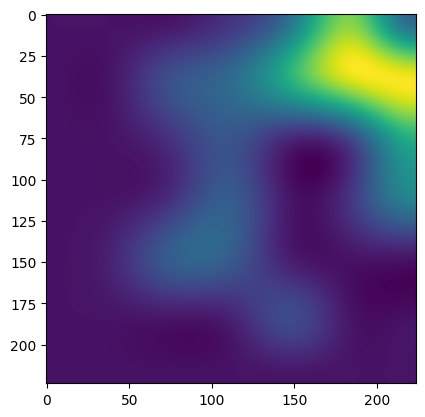

In [34]:
plt.imshow(ndimage.zoom(cams[3], zoom=(32,32)))

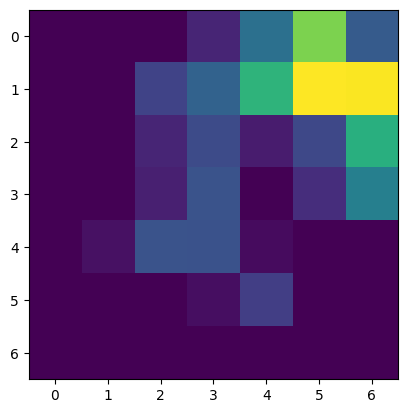

In [15]:
plt.imshow(cams[3])